# Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier


from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score,
    confusion_matrix,
    precision_recall_curve,
)

import warnings
warnings.filterwarnings("ignore")

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)    
# setting the precision of floating numbers to 2 decimal points
pd.set_option("display.float_format", lambda x: "%.2f" % x)

# Load Data

In [2]:
data = pd.read_csv('PS_20174392719_1491204439457_log.csv')

In [3]:
df = data.copy()

# Functions

In [4]:
def evaluate_model(name, y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"{'='*40}")
    print(f"ROC-AUC:           {roc_auc_score(y_true, y_proba):.4f}")
    print(f"PR-AUC:            {average_precision_score(y_true, y_proba):.4f}")
    print(f"Recall (Fraud):    {recall_score(y_true, y_pred):.4f}")
    print(f"Precision (Fraud): {precision_score(y_true, y_pred):.4f}")
    print(f"F1 Score:          {f1_score(y_true, y_pred):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

# Analysis

## Data Preprocessing

### Mapping and encoding

In [5]:
df['type_encoded'] = df['type'].map({
    'CASH_IN': 0,
    'CASH_OUT': 1,
    'DEBIT': 2,
    'PAYMENT': 3,
    'TRANSFER': 4
})

### Feature engineering

In [6]:
# check discrepancies between before and after customer who started the transaction, no error = 0
# large positive value means unjustified extra amount after the transaction is done
# large negative value means unjustified amount lost during the transaction
df['errorBalanceOrg'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']

# check discrepancies between before and after of recipient balance, no error = 0
# large positive value means unjustified money lost during the transaction
# large negative value means unjustified extra money received.
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# flag CASH_OUT and TRANSFER
df['is_risky_type'] = df['type'].isin(['CASH_OUT', 'TRANSFER']).astype(int)

# flag 0 balance
df['orig_zero_balance'] = (df['newbalanceOrig'] == 0).astype(int)
df['dest_zero_balance'] = (df['newbalanceDest'] == 0).astype(int)

# amount to balance ratio, how large is this transaction relative to account
df['amount_to_orig_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)

## Data Preparation

In [7]:
features = [
    'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest', 'type_encoded',
    'errorBalanceOrg', 'errorBalanceDest', 'is_risky_type',
    'orig_zero_balance', 'dest_zero_balance', 'amount_to_orig_ratio'
]

X = df[features]
y = df['isFraud']

In [8]:
print(X.shape)
print(y.value_counts())

(6362620, 13)
isFraud
0    6354407
1       8213
Name: count, dtype: int64


### Splitting

In [9]:
# First split — 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Second split — split temp into 50/50 validation and test (10% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(f"Train size: {X_train.shape}")
print(f"Val size:   {X_val.shape}")
print(f"Test size:  {X_test.shape}")
print(f"Train fraud rate: {y_train.mean()*100:.4f}%")
print(f"Val fraud rate:   {y_val.mean()*100:.4f}%")
print(f"Test fraud rate:  {y_test.mean()*100:.4f}%")

Train size: (5090096, 13)
Val size:   (636262, 13)
Test size:  (636262, 13)
Train fraud rate: 0.1291%
Val fraud rate:   0.1292%
Test fraud rate:  0.1290%


In [10]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

scale_pos_weight: 773.75


## Modelling

### Model evaluation criterion:

**Model can make wrong predictions as:**
- Predicting fraud but its not fraud (FP).
- Predicting not fraud but its a fraud (FN).

**Which case is more important?**
- Predicting FN leads to severe consequences.

Recall score will be the primary metric score.

### Pipeline

#### logit

In [11]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000,
                                solver='lbfgs', C=1.0))
])

In [12]:
# params = {
#     'model__C': [0.01, 0.1, 1, 10, 100],
#     'model__solver': ['lbfgs', 'saga'],
#     'model__penalty': ['l2']
# }

In [13]:
%%time
# lr_search = RandomizedSearchCV(
#     lr_pipeline,
#     param_distributions=params,
#     n_iter=5,
#     scoring='average_precision',
#     cv=3,
#     random_state=42,
#     n_jobs=-1,
#     verbose=2
# )

lr_pipeline.fit(X_train, y_train)

CPU times: total: 26.5 s
Wall time: 14.8 s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not wo


Model: Logistic Regression
ROC-AUC:           0.9948
PR-AUC:            0.6909
Recall (Fraud):    0.9601
Precision (Fraud): 0.0499
F1 Score:          0.0948


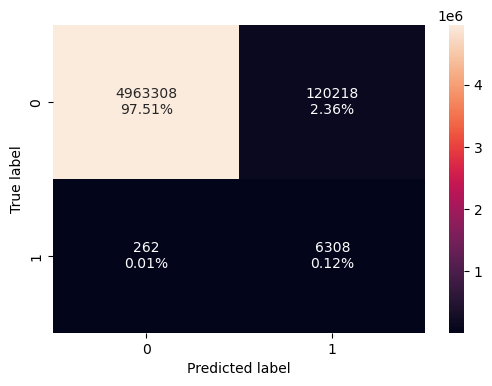

In [14]:
lr_train_proba = lr_pipeline.predict_proba(X_train)[:, 1]
evaluate_model("Logistic Regression", y_train, lr_train_proba)

#### Light GBM

In [15]:
lgbm_pipeline = Pipeline([
    ('model', LGBMClassifier(
        random_state=42,
        n_jobs=1,
        scale_pos_weight=scale_pos_weight
    ))
])

In [16]:
params = {
    'model__n_estimators': [100, 300, 500],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__num_leaves': [31, 63, 127],
    'model__min_child_samples': [20, 50, 100]
}

In [17]:
%%time
lgbm_search = RandomizedSearchCV(
    lgbm_pipeline,
    param_distributions=params,
    n_iter=10,
    scoring='average_precision',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)


lgbm_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Number of positive: 6570, number of negative: 5083526
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.108492 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2306
[LightGBM] [Info] Number of data points in the train set: 5090096, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001291 -> initscore=-6.651247
[LightGBM] [Info] Start training from score -6.651247
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Li

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...496194825)))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [4, 6, ...], 'model__min_child_samples': [20, 50, ...], 'model__n_estimators': [100, 300, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-v

In [18]:
print(f"Best params: {lgbm_search.best_params_}")
print(f"Best CV PR-AUC: {lgbm_search.best_score_:.4f}")

Best params: {'model__num_leaves': 31, 'model__n_estimators': 500, 'model__min_child_samples': 100, 'model__max_depth': 4, 'model__learning_rate': 0.01}
Best CV PR-AUC: 0.9971



Model: LightGBM
ROC-AUC:           1.0000
PR-AUC:            0.9997
Recall (Fraud):    0.9991
Precision (Fraud): 0.8900
F1 Score:          0.9414


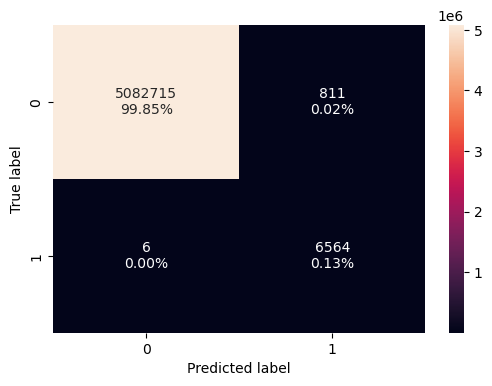

In [19]:
lgbm_train_proba = lgbm_search.predict_proba(X_train)[:, 1]
evaluate_model("LightGBM", y_train, lgbm_train_proba)

#### XGB

In [20]:
xgb_pipeline = Pipeline([
    ('model', XGBClassifier(
        random_state=42,
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
        eval_metric='aucpr',
        verbosity=0
    ))
])

In [21]:
params = {
    'model__n_estimators': [100, 300, 500],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__subsample': [0.7, 0.8, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 1.0],
    'model__min_child_weight': [1, 5, 10]
}

In [22]:
%%time
xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=params,
    n_iter=10,
    scoring='average_precision',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

xgb_search.fit(X_train,y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
CPU times: total: 3min 11s
Wall time: 9min 28s


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [4, 6, ...], 'model__min_child_weight': [1, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscros

In [23]:
print(f"Best params: {xgb_search.best_params_}")
print(f"Best CV AUC: {xgb_search.best_score_:.4f}")

Best params: {'model__subsample': 0.7, 'model__n_estimators': 100, 'model__min_child_weight': 1, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.7}
Best CV AUC: 0.9973



Model: XGB
ROC-AUC:           1.0000
PR-AUC:            0.9991
Recall (Fraud):    0.9979
Precision (Fraud): 0.9162
F1 Score:          0.9553


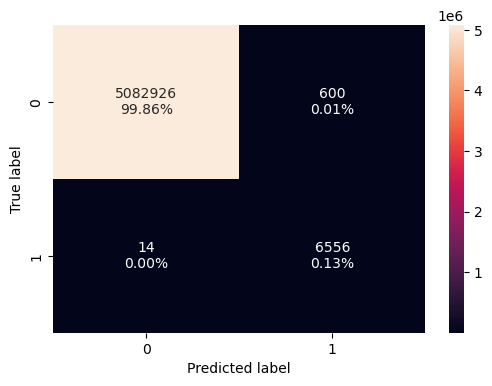

In [24]:
xgb_train_proba = xgb_search.predict_proba(X_train)[:, 1]
evaluate_model("XGB", y_train, xgb_train_proba)

### Model Evaluation

#### Validation


Model: Logistic Regression
ROC-AUC:           0.9964
PR-AUC:            0.7011
Recall (Fraud):    0.9672
Precision (Fraud): 0.0501
F1 Score:          0.0952

Model: LightGBM
ROC-AUC:           0.9999
PR-AUC:            0.9976
Recall (Fraud):    0.9976
Precision (Fraud): 0.8789
F1 Score:          0.9345

Model: XGB
ROC-AUC:           0.9999
PR-AUC:            0.9987
Recall (Fraud):    0.9988
Precision (Fraud): 0.9225
F1 Score:          0.9591


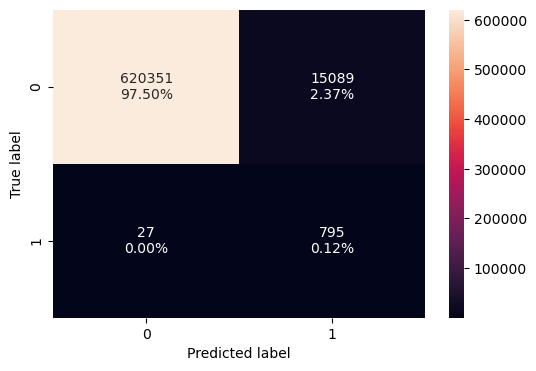

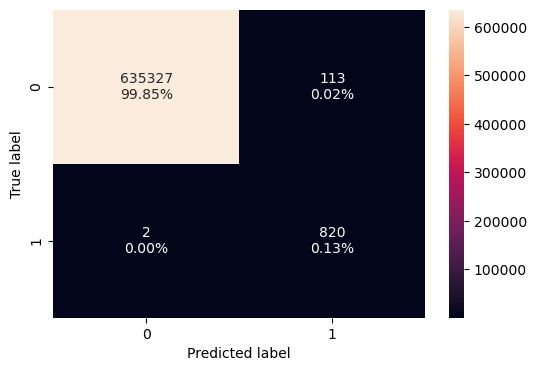

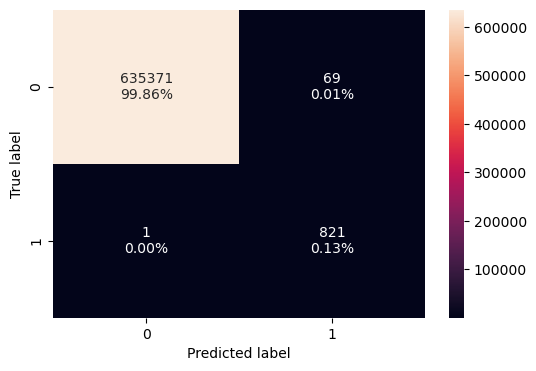

In [25]:
lr_val_proba = lr_pipeline.predict_proba(X_val)[:, 1]
lgbm_val_proba = lgbm_search.predict_proba(X_val)[:, 1]
xgb_val_proba = xgb_search.predict_proba(X_val)[:, 1]

evaluate_model("Logistic Regression", y_val, lr_val_proba)
evaluate_model("LightGBM", y_val, lgbm_val_proba)
evaluate_model("XGB", y_val, xgb_val_proba)

##### Threshold tuning for XGBoost

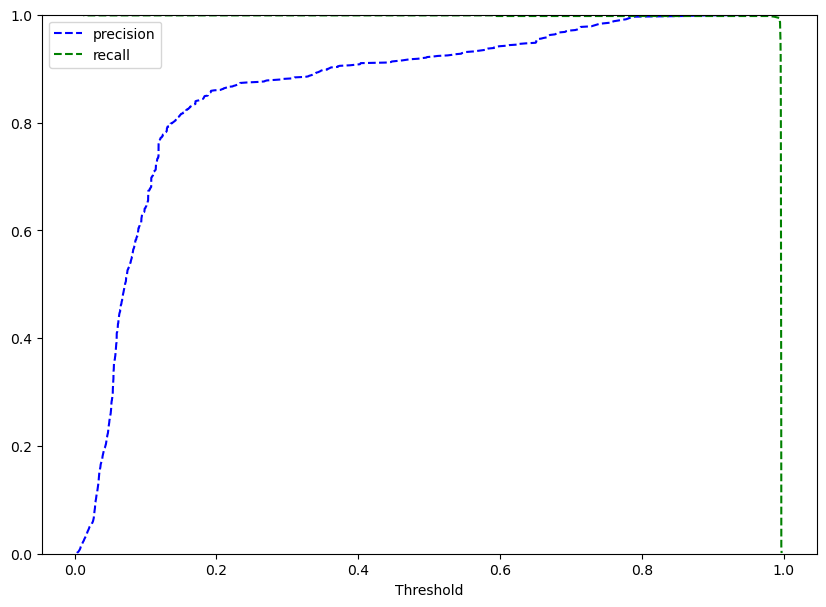

In [28]:
precisions, recalls, thresholds = precision_recall_curve(y_val, xgb_val_proba)

def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])
    
def intersection(lst1, lst2):
    lst3 = [value for value in lst1 if value in lst2]
    return lst3

plt.figure(figsize=(10, 7))
plot_prec_recall_vs_tresh(precisions, recalls, thresholds)
plt.show()

In [33]:
recall_slice = recalls[(0.95 < recalls) & (recalls < 1.0)].tolist()
precision_slice = precisions[(0.95 < precisions) & (precisions < 1.0)].tolist()

In [34]:
# searching the intersection point of recall and precision
print(intersection(recall_slice,precision_slice))
intersected = intersection(recall_slice,precision_slice)

[0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691, 0.9975669099756691]


In [35]:
# extract the threshold 
intersect = pd.DataFrame({'prec': precisions[:-1],
                          'rec': recalls[:-1],
                          'tre': thresholds})

intersect[intersect['prec'] == 0.9975669099756691]

,prec,rec,tre
36109,1.00,1.00,0.86


In [36]:
# setting the threshold
optimal_threshold_curve = 0.86

#### Test


Model: Logistic Regression
ROC-AUC:           0.9951
PR-AUC:            0.6914
Recall (Fraud):    0.9635
Precision (Fraud): 0.0496
F1 Score:          0.0943

Model: LightGBM
ROC-AUC:           0.9998
PR-AUC:            0.9988
Recall (Fraud):    0.9988
Precision (Fraud): 0.8855
F1 Score:          0.9388

Model: XGB
ROC-AUC:           0.9999
PR-AUC:            0.9988
Recall (Fraud):    0.9988
Precision (Fraud): 0.9041
F1 Score:          0.9491

Model: XGBoost - Test (threshold=0.86)
ROC-AUC:           0.9999
PR-AUC:            0.9988
Recall (Fraud):    0.9976
Precision (Fraud): 0.9903
F1 Score:          0.9939


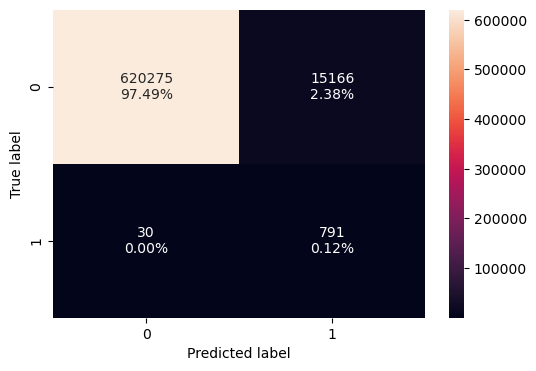

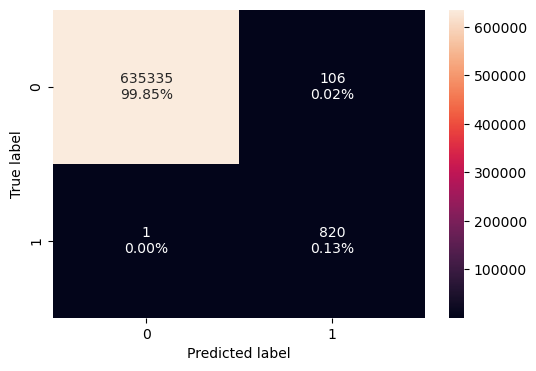

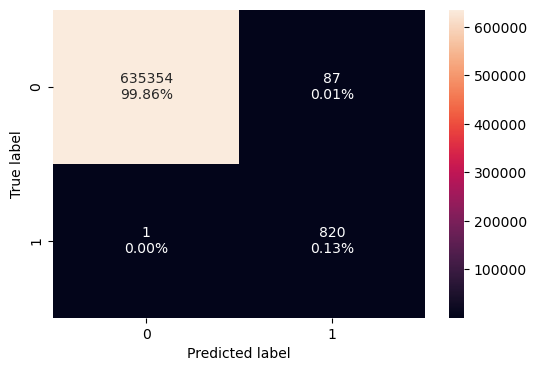

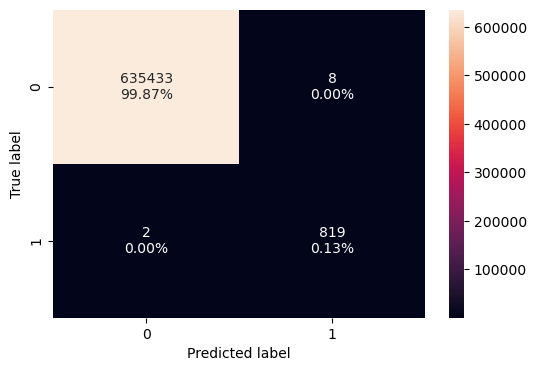

In [37]:
lr_test_proba = lr_pipeline.predict_proba(X_test)[:, 1]
lgbm_test_proba = lgbm_search.predict_proba(X_test)[:, 1]
xgb_test_proba = xgb_search.predict_proba(X_test)[:, 1]

xgb_test_proba = xgb_search.predict_proba(X_test)[:, 1]


evaluate_model("Logistic Regression", y_test, lr_test_proba)
evaluate_model("LightGBM", y_test, lgbm_test_proba)
evaluate_model("XGB", y_test, xgb_test_proba)
evaluate_model("XGBoost - Test (threshold=0.86)", y_test, xgb_test_proba, threshold=0.86)

### Model Selection

- Due to non-linearity nature of fraud patterns, logistic regression is expected to underperform.
- XGB model proves to be the strongest performer with optimal threshold of 0.86. 
- The model missed 2 fraudulent transaction.
- The model has the lowest falsely predicted fraud, namely 8 FP.

In [38]:
import joblib

In [39]:
joblib.dump(xgb_search.best_estimator_, 'xgb_fraud_model.pkl')
print("Model saved.")

Model saved.
